In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

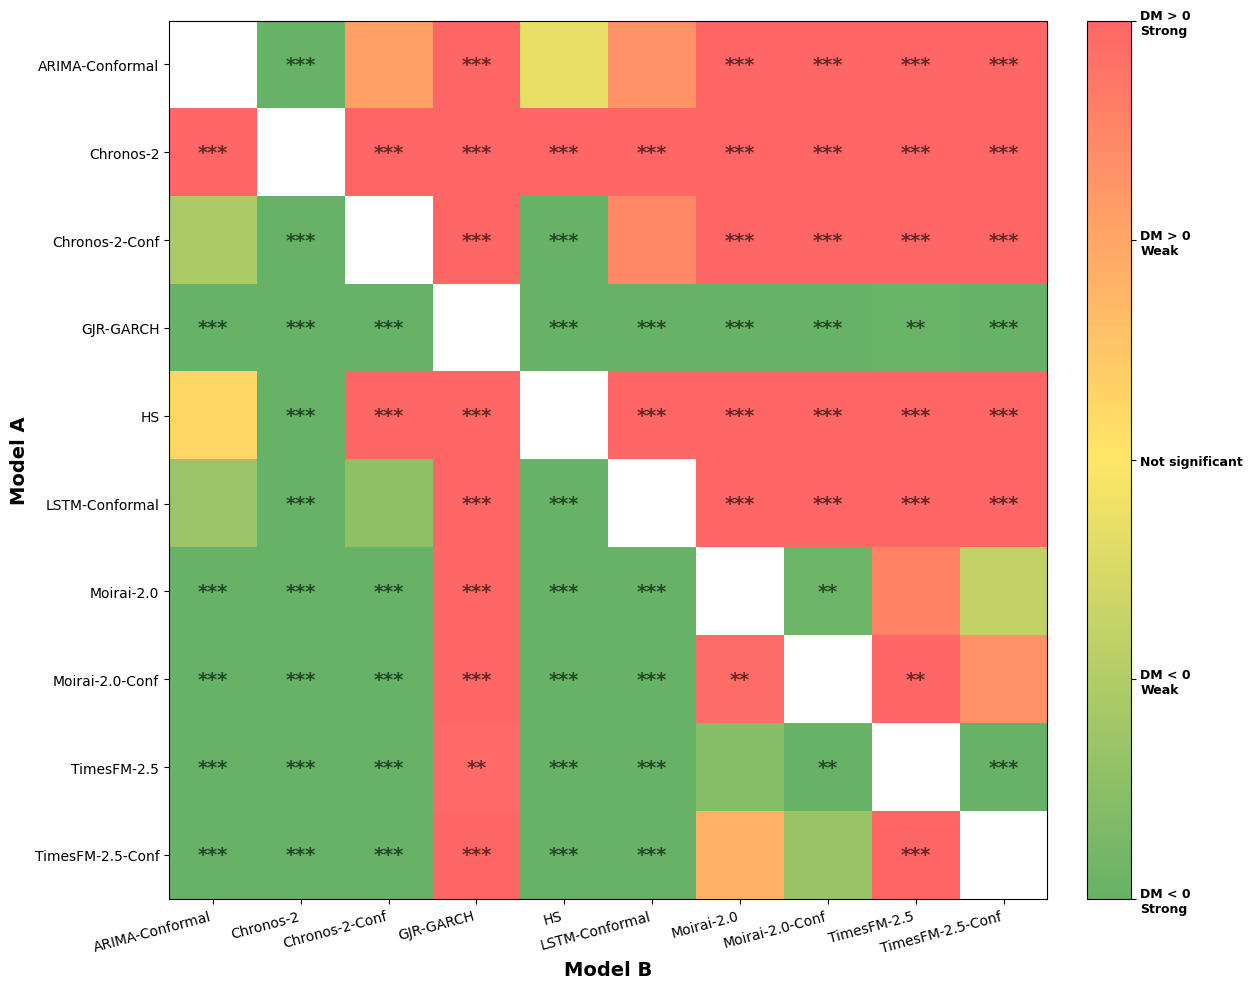

In [ ]:
csv_path = "dm_tick_loss_1pct.csv"
df = pd.read_csv(csv_path)

models = sorted(set(df["model_i"]).union(set(df["model_j"])))

p_mat = pd.DataFrame(np.nan, index=models, columns=models)
dm_mat = pd.DataFrame(np.nan, index=models, columns=models)

for _, row in df.iterrows():
    i = row["model_i"]
    j = row["model_j"]
    p = row["p_value"]
    dm = row["DM_stat"]

    p_mat.loc[i, j] = pㄋ
    dm_mat.loc[i, j] = dm

    p_mat.loc[j, i] = p
    dm_mat.loc[j, i] = -dm

for m in models:
    p_mat.loc[m, m] = np.nan
    dm_mat.loc[m, m] = np.nan

sig_strength = 1 - p_mat
heat_val = np.sign(dm_mat) * sig_strength

masked_heat = np.ma.masked_invalid(heat_val.values)

cmap = LinearSegmentedColormap.from_list("morandi_green_yellow_red", ["green", "gold", "red"]).copy()
cmap.set_bad("white")

norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(masked_heat, cmap=cmap, norm=norm, alpha=0.6)

ax.set_xticks(np.arange(len(models)))
ax.set_yticks(np.arange(len(models)))
ax.set_xticklabels(models, rotation=15, ha="right")
ax.set_yticklabels(models)

for i in range(len(models)):
    for j in range(len(models)):
        p = p_mat.iloc[i, j]

        if pd.isna(p):
            text = ""
        elif p < 0.01:
            text = "***"
        elif p < 0.05:
            text = "**"
        elif p < 0.10:
            text = "*"
        else:
            text = ""

        ax.text(j, i, text, ha="center", va="center", fontsize=14, color="black", fontweight='heavy', alpha=0.6)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.set_ticklabels(["DM < 0\nStrong", "DM < 0\nWeak", "Not significant", "DM > 0\nWeak", "DM > 0\nStrong"], fontsize=14, fontweight='bold')

cbar.ax.tick_params(labelsize=9)

plt.xlabel("Model B", fontsize=14, fontweight="bold")
plt.ylabel("Model A", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("dm_heatmap.png", dpi=300, transparent=True)
plt.show()